In [1]:
# WEB DEV TEAM PLEASE DELETE BEFORE PUBLISHING - DS TEAM PLEASE KEEP IN THE FINAL VERSION OF THE USE CASE

from IPython.core.display import HTML
HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@600;700&family=Inter:wght@400;500&display=swap');
body,p,li,div{font-family:'Inter',sans-serif}
body{counter-reset:h2counter}
.usecase-header-bar,.usecase-title,.usecase-section-heading,.usecase-sub-section-heading,.usecase-sub-sub-section-heading,.usecase-unnumbered-heading{font-family:'Poppins',sans-serif}
.usecase-header-bar{padding:16px 20px;background-color:#059669;color:#fff;border-radius:6px 6px 0 0}
.usecase-title{font-size:1.9em;font-weight:800}
.usecase-details{padding-left:20px;padding-bottom:8px;padding-top:8px;font-size:1.1em;color:#121212}
.usecase-section-heading,.usecase-unnumbered-heading{font-weight:700;font-size:1.35em;color:#059669;padding:14px 4px 6px 4px;border-bottom:3px solid #2DBE6C;margin-top:10px}
.usecase-section-heading::before{content:none!important}
.usecase-sub-section-heading{font-weight:600;font-size:1.15em;color:#059669;margin-top:8px}
.usecase-sub-section-heading::before{content:none!important}
.usecase-sub-sub-section-heading{font-weight:500;font-size:1.05em;color:#059669;margin-top:6px}
.usecase-sub-sub-section-heading::before{content:none!important}
.usecase-body{font-size:1em;color:#121212;line-height:1.6;margin-bottom:8px}
.usecase-list{line-height:1.7}
.usecase-list ul,.usecase-list ol{padding-left:24px;margin-top:8px;margin-bottom:12px}
.usecase-list li{margin-bottom:6px}
.usecase-datasets{background-color:rgba(5,150,105,.06);border-left:4px solid #059669;padding:12px 20px;border-radius:0 4px 4px 0;margin-top:12px}
.usecase-datasets ul{margin-top:8px;margin-bottom:8px}
.usecase-contents a,.usecase-datasets a{color:#059669;text-decoration:none}
.usecase-datasets a{font-weight:500}
.usecase-contents a:hover,.usecase-datasets a:hover{text-decoration:underline}
.usecase-contents{line-height:1.9;padding-left:20px}
</style>
""")

<div class="usecase-header-bar">
    <div class="usecase-title">Melbourne Employment and Industry Analysis 2002 - 2024</div>
</div>

<div class="usecase-details"><b>Authored by: </b>Aayush Amitbhai Patel</div>
<div class="usecase-details"><b>Date Created: </b>Trimester 1, 2024</div>
<div class="usecase-details"><b>Time to Complete: </b>105 mins</div>
<div class="usecase-details"><b>Level: </b>Intermediate</div>
<div class="usecase-details"><b>Pre-requisite Skills: </b>Python, pandas, scikit-learn and REST APIs</div>

<div id="scenario" class="usecase-unnumbered-heading"><b>Scenario</b></div>

<div class="usecase-body">

As a City of Melbourne workforce planner, I want an estimate of job numbers for combinations of precinct, industry and business size that are not directly observed in the published data so that planning decisions are not limited to the combinations that happen to appear in the Census of Land Use and Employment (CLUE).

</div>

<div id="what-this-teaches" class="usecase-unnumbered-heading"><b>What this usecase will teach you</b></div>

<div class="usecase-body">

After working through this use case you will be able to:

</div>

<div class="usecase-list">

- Retrieve an open dataset programmatically from the City of Melbourne Open Data Portal using its Explore API.
- Analyse how business establishments and jobs are distributed across industries and business sizes in Melbourne.
- Identify the industry sectors that contribute most to job creation in the municipality.
- Join tabular data to a spatial boundary file and map it with `folium` to see where employment is concentrated across the municipality.
- Assess and treat missing values and statistical outliers in a real-world administrative dataset.
- Build a scikit-learn `Pipeline` that bundles preprocessing and the model into a single object, so training and inference apply exactly the same transformations.
- Use a `ColumnTransformer` to route numeric and categorical columns through different treatments.
- Train and evaluate a Random Forest regression model that estimates total jobs.
- Interpret regression metrics (MAE, RMSE and R-squared), cross-validate them and recognise their limitations.

</div>

<div id="background" class="usecase-unnumbered-heading"><b>Background</b></div>

<div class="usecase-body">

The Census of Land Use and Employment (CLUE) is a survey the City of Melbourne has run since 2002, covering every business establishment operating within the municipality. An establishment is counted per location rather than per enterprise, so an organisation occupying several buildings is counted several times.

Each record reports the number of establishments and the number of jobs for a combination of three categories: the CLUE small area (a precinct such as Carlton or Docklands), the CLUE industry classification, and the business size band. The City of Melbourne publishes a parallel series classified by Australian and New Zealand Standard Industrial Classification (ANZSIC) industry division rather than CLUE industry; this use case works with the CLUE industry series.

Because the data is confidentialised, any cell covering two or fewer businesses is suppressed and appears blank. That suppression is the source of most of the missing values encountered later in this notebook, and understanding it is essential to treating them sensibly.

</div>

<div id="data-sets" class="usecase-unnumbered-heading"><b>Data Sets</b></div>

<div class="usecase-body">

The CLUE industry series covers census years from 2002 onwards and is retrieved live through the Opendatasoft Explore API, so the notebook always works against the current release rather than a stored copy. The data is published by the City of Melbourne under a Creative Commons Attribution licence. The parallel ANZSIC industry series is available from the same catalogue and is not used here. All of the analysis and modelling in this use case comes from that single table. It already carries the year, the small area, the industry, the business size, the number of establishments and the number of jobs, and since the question is how those things relate to one another, it can be answered without joining anything else in. A second table of variables would only add columns the model has no use for.

The one exception is the CLUE small areas boundary file, listed below. It contains no employment figures at all &mdash; only the shape of each precinct &mdash; and is used purely so the job counts can be drawn on a map in section 3.3.

</div>



<div class="usecase-datasets">

- [Business establishments and jobs by business size and CLUE industry](https://data.melbourne.vic.gov.au/explore/dataset/business-establishments-and-jobs-data-by-business-size-and-clue-industry/)
- [Small Areas for Census of Land Use and Employment (CLUE)](https://data.melbourne.vic.gov.au/explore/dataset/small-areas-for-census-of-land-use-and-employment-clue/)

</div>

<div class="usecase-contents"><b>Contents</b></div>

<div class="usecase-contents">

1. <a href="#section-1">Set up the Python environment</a><br>
2. <a href="#section-2">Retrieve the dataset through the API</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;2.1. <a href="#section-2-1">Inspect the structure of the data</a><br>
3. <a href="#section-3">Descriptive analysis</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;3.1. <a href="#section-3-1">Jobs and establishments by industry</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;3.2. <a href="#section-3-2">Total jobs across census years</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;3.3. <a href="#section-3-3">Mapping jobs across small areas</a><br>
4. <a href="#section-4">Prepare the data for modelling</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;4.1. <a href="#section-4-1">Missing job counts</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;4.2. <a href="#section-4-2">Outliers</a><br>
5. <a href="#section-5">Build the modelling pipeline</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;5.1. <a href="#section-5-1">Why a pipeline rather than encoding by hand</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;5.2. <a href="#section-5-2">Assemble and fit the pipeline</a><br>
6. <a href="#section-6">Evaluate the model</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;6.1. <a href="#section-6-1">Cross-validate the pipeline</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;6.2. <a href="#section-6-2">Which features drive the predictions</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;6.3. <a href="#section-6-3">Predicted against actual values</a><br>
7. <a href="#section-7">Estimate jobs for a new combination of inputs</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;7.1. <a href="#section-7-1">Behaviour on an unfamiliar category</a><br>

</div>

<div id="section-1" class="usecase-section-heading">
    1. Set up the Python environment
</div>

<div class="usecase-body">

In this section we will import the libraries that are used for data retrieval, statistics, visualisation and modelling throughout the use case.

The notebook relies on `requests` to call the Open Data Portal API, `pandas` for data manipulation, `scipy` for the outlier calculation, `seaborn` and `matplotlib` for visualisation, and `scikit-learn` for the pipeline, the model and its evaluation metrics. The scikit-learn imports are grouped by role: `compose` and `pipeline` assemble the workflow, `impute` and `preprocessing` supply the transformation steps, `ensemble` supplies the estimator, and `model_selection` and `metrics` handle splitting and scoring.

</div>

In [2]:
# Data retrieval and handling
import requests
import pandas as pd
from io import StringIO

# Statistics
from scipy import stats

# Visualisation
import seaborn as sns
import matplotlib.pyplot as plt
import folium

# Pipeline assembly
from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Preprocessing steps
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Modelling and evaluation
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Display all columns when previewing DataFrames
pd.set_option('display.max_columns', None)

# Render fitted pipelines as an interactive diagram rather than plain text
set_config(display='diagram')

# Consistent colour scheme for all plots in this notebook
PRIMARY_GREEN = '#059669'
DEEP_GREEN = '#1F8F50'
DARK_GREEN = '#15803D'

<div id="section-2" class="usecase-section-heading">
    2. Retrieve the dataset through the API
</div>

<div class="usecase-body">

The City of Melbourne Open Data Portal exposes every dataset through the Opendatasoft Explore API. The helper function below builds an export URL from a dataset identifier and returns the result as a DataFrame.

Two details are worth noting. Setting `limit` to `-1` requests the complete dataset rather than the default first page of records. The CSV export is semicolon-delimited, not comma-delimited, so `pd.read_csv` needs `delimiter=';'` to parse it correctly.

</div>

In [3]:
def datasetcollect(dataset_id):
    """Retrieve a City of Melbourne open dataset as a pandas DataFrame.

    Parameters
    ----------
    dataset_id : str
        The dataset identifier as it appears on the Open Data Portal.

    Returns
    -------
    pandas.DataFrame
        The full dataset.

    Raises
    ------
    requests.HTTPError
        If the API does not return a successful response.
    """
    base_url = 'https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/'
    url = f'{base_url}{dataset_id}/exports/csv'

    params = {
        'select': '*',
        'limit': -1,       # -1 returns all records rather than the first page
        'lang': 'en',
        'timezone': 'UTC',
    }

    response = requests.get(url, params=params)
    response.raise_for_status()

    # The portal's CSV export is semicolon-delimited
    return pd.read_csv(StringIO(response.content.decode('utf-8')), delimiter=';')

<div class="usecase-body">

Now that the helper function is in place, we can call it with the CLUE industry dataset identifier and take a look at the shape of what comes back.

</div>

In [4]:
dataset_id = 'business-establishments-and-jobs-data-by-business-size-and-clue-industry'

buss_est = datasetcollect(dataset_id)

print(f'Retrieved {len(buss_est):,} rows and {buss_est.shape[1]} columns.')
print('Columns:', list(buss_est.columns))

Retrieved 14,107 rows and 6 columns.
Columns: ['census_year', 'clue_small_area', 'clue_industry', 'business_size', 'total_establishments', 'total_jobs']


<div class="usecase-body">

If the cell above reports a 404, the dataset identifier has changed on the portal. Search the Open Data Portal for &quot;business establishments and jobs&quot;, pick the entry whose title mentions CLUE industry in small areas, and substitute its identifier before continuing.

The column list is printed alongside the row count because a replacement dataset does not necessarily carry the same columns as the retired one. The cells below read the column names from the data rather than assuming a fixed set.

</div>

<div id="section-2-1" class="usecase-sub-section-heading">
    2.1. Inspect the structure of the data
</div>

<div class="usecase-body">

Before any analysis, it is worth establishing what the dataset actually contains: its shape, the type of each column, the range of the numeric fields and where values are missing. The four cells below do exactly that.

</div>

In [5]:
buss_est.head()

,census_year,clue_small_area,clue_industry,business_size,total_establishments,total_jobs
0,2002,West Melbourne (Industrial),Construction,Small business,3,8.0
1,2002,West Melbourne (Industrial),"Electricity, Gas, Water and Waste Services",Medium business,1,NaN
2,2002,West Melbourne (Industrial),Food and Beverage Services,Small business,10,36.0
3,2002,West Melbourne (Industrial),Other Services,Small business,8,47.0
4,2002,West Melbourne (Industrial),Retail Trade,Small business,8,37.0


In [6]:
buss_est.describe()

,census_year,total_establishments,total_jobs
count,14107.000000,14107.000000,9496.000000
mean,2013.207982,24.480542,931.580034
std,6.587369,101.839228,2803.193610
min,2002.000000,1.000000,0.000000
25%,2008.000000,2.000000,39.000000
50%,2013.000000,5.000000,157.000000
75%,2019.000000,14.000000,517.000000
max,2024.000000,1535.000000,30191.000000


In [7]:
buss_est.dtypes

census_year               int64
clue_small_area          object
clue_industry            object
business_size            object
total_establishments      int64
total_jobs              float64
dtype: object

In [8]:
missing_values = buss_est.isnull().sum()
missing_pct = (missing_values / len(buss_est) * 100).round(1)

pd.DataFrame({'missing': missing_values, 'percent': missing_pct})

,missing,percent
census_year,0,0.0
clue_small_area,0,0.0
clue_industry,0,0.0
business_size,0,0.0
total_establishments,0,0.0
total_jobs,4611,32.7


<div class="usecase-body">

Five of the six columns are complete. The exception is `total_jobs`, where 4,611 of the 14,107 rows have no value &mdash; 32.7 per cent of the dataset. That is a substantial gap and needs a deliberate decision before modelling, which is addressed in section 4.

</div>

<div id="section-3" class="usecase-section-heading">
    3. Descriptive analysis
</div>

<div class="usecase-body">

In this section we will remove any aggregate rows supplied by the portal and then summarise establishments and jobs by industry.

The City of Melbourne has historically supplied aggregate rows alongside the detail rows, using labels such as &quot;All CLUE Industry&quot; and &quot;City of Melbourne (total)&quot;. These are subtotals rather than observations, and leaving them in would leak totals into a model trained to predict the parts. The cell below checks every categorical column for them.

</div>

In [9]:
# Read the categorical columns from the data rather than hardcoding them. The
# portal has used both 'anzsic_indusrty' (a typo in the source) and 'anzsic_industry',
# and the current CLUE industry dataset carries neither.
CANDIDATE_CATEGORICALS = [
    'clue_small_area',
    'anzsic_indusrty',
    'anzsic_industry',
    'clue_industry',
    'business_size',
]
CATEGORICAL_COLUMNS = [c for c in CANDIDATE_CATEGORICALS if c in buss_est.columns]

print('Categorical columns in use:', CATEGORICAL_COLUMNS)

# Aggregate rows supplied by the City of Melbourne. These are totals rather than
# observations, so they are excluded from every analysis below.
AGGREGATE_LABELS = [
    'All CLUE Industry',
    'All ANZSIC',
    'City of Melbourne (total)',
    'City of Melbourne',
    'Total',
]

keep = pd.Series(True, index=buss_est.index)
for col in CATEGORICAL_COLUMNS:
    hits = buss_est[col].isin(AGGREGATE_LABELS)
    print(f'  {col}: {hits.sum():,} aggregate rows')
    keep &= ~hits

buss_est_detail = buss_est[keep]

print(f'\n{len(buss_est):,} rows total, {len(buss_est_detail):,} after removing aggregates.')

summary_stats = (
    buss_est_detail
    .groupby('clue_industry')[['total_establishments', 'total_jobs']]
    .sum()
    .sort_values('total_jobs', ascending=False)
)

summary_stats

Categorical columns in use: ['clue_small_area', 'clue_industry', 'business_size']
  clue_small_area: 0 aggregate rows
  clue_industry: 0 aggregate rows
  business_size: 0 aggregate rows

14,107 rows total, 14,107 after removing aggregates.


,total_establishments,total_jobs
clue_industry,,
Business Services,57097,1587635.0
Finance and Insurance,19930,1330076.0
Public Administration and Safety,6380,839354.0
Health Care and Social Assistance,22798,778326.0
Information Media and Telecommunications,7104,615525.0
Food and Beverage Services,52219,598465.0
Education and Training,11906,459043.0
Retail Trade,50494,424044.0
Arts and Recreation Services,12923,415645.0


<div class="usecase-body">

In this release the check finds none &mdash; the small areas dataset contains detail rows only, and the municipality-wide totals live in a separate dataset on the portal. The check is retained because it costs nothing, documents an assumption that a reader would otherwise have to verify, and will catch the aggregates if the portal reinstates them.

The summary statistics show how establishments and jobs are distributed across industries under the CLUE classification. Business Services, Finance and Insurance, Public Administration and Safety, and Health Care stand out with large job numbers, reflecting their weight in the local economy. Notably, the ranking by jobs differs from the ranking by establishments: Retail Trade and Food and Beverage Services have among the most establishments but far fewer jobs, because those industries are dominated by small businesses.

</div>

<div id="section-3-1" class="usecase-sub-section-heading">
    3.1. Jobs and establishments by industry
</div>

<div class="usecase-body">

Here we compare the industries directly by ranking them on their job and establishment counts. Plotting the two charts side by side makes the difference between the rankings much easier to see.

</div>

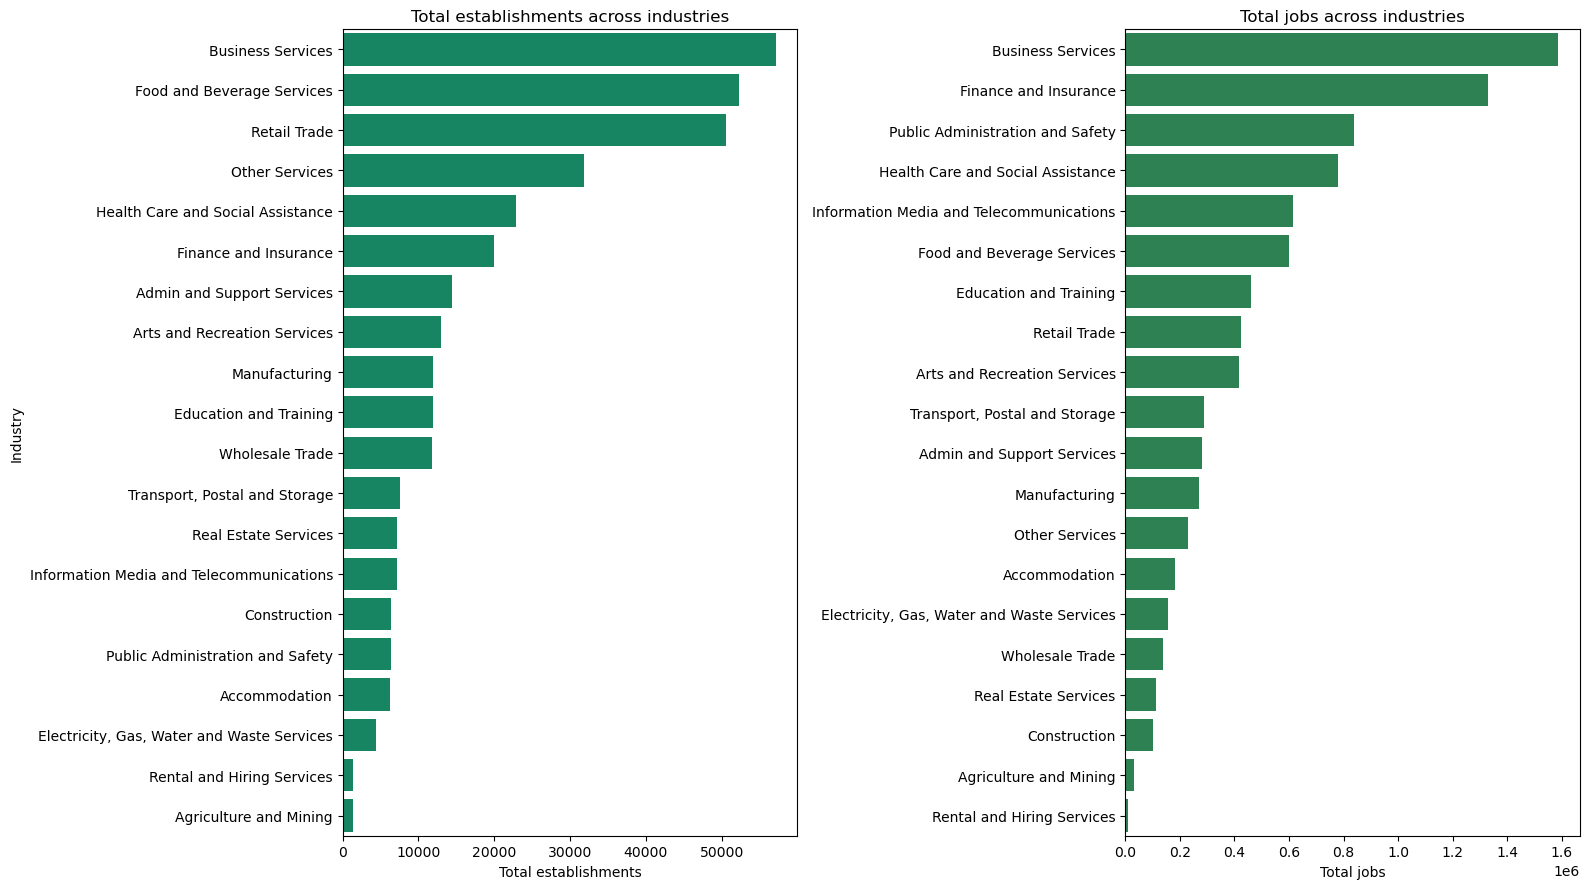

In [10]:
# Aggregate to one row per industry before plotting, so the bars show totals
industry_totals = summary_stats.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 9))

sns.barplot(
    data=industry_totals.sort_values('total_establishments', ascending=False),
    x='total_establishments', y='clue_industry',
    color=PRIMARY_GREEN, ax=axes[0]
)
axes[0].set(title='Total establishments across industries',
            xlabel='Total establishments', ylabel='Industry')

sns.barplot(
    data=industry_totals.sort_values('total_jobs', ascending=False),
    x='total_jobs', y='clue_industry',
    color=DEEP_GREEN, ax=axes[1]
)
axes[1].set(title='Total jobs across industries',
            xlabel='Total jobs', ylabel='')

plt.tight_layout()
plt.show()

<div class="usecase-body">

The comparison confirms the concentration seen in the summary statistics: a handful of industries account for a disproportionate share of employment, while a long tail of industries contribute comparatively few jobs despite having a reasonable number of establishments.

</div>

<div id="section-3-2" class="usecase-sub-section-heading">
    3.2. Total jobs across census years
</div>

<div class="usecase-body">

In this step we aggregate the figures across all industries so we can see how total employment in the municipality has moved across successive census years.

</div>

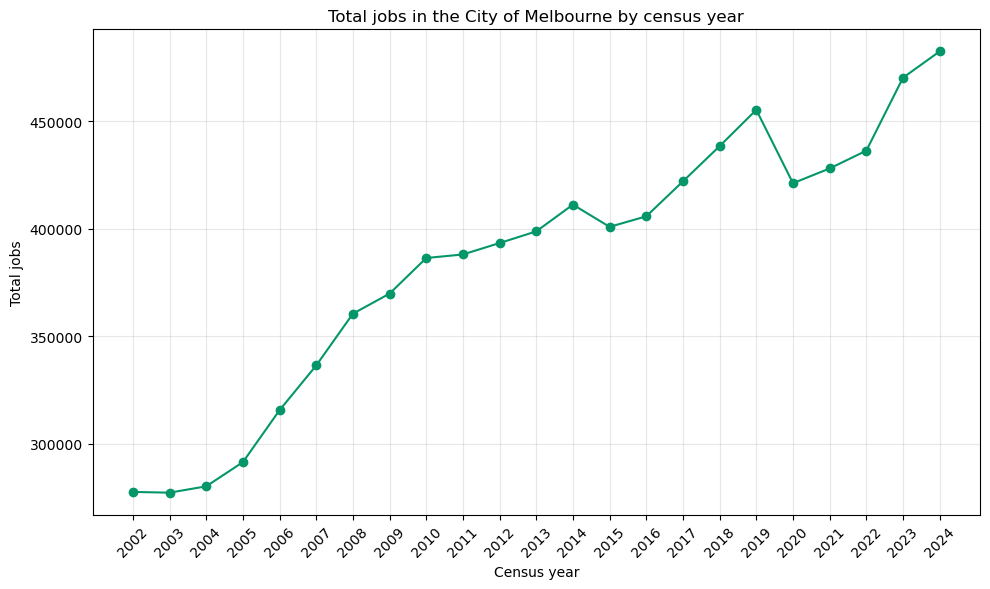

In [11]:
df_yearly = (
    buss_est_detail
    .groupby('census_year')['total_jobs']
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 6))
plt.plot(df_yearly['census_year'], df_yearly['total_jobs'],
         marker='o', color=PRIMARY_GREEN)
plt.title('Total jobs in the City of Melbourne by census year')
plt.xlabel('Census year')
plt.ylabel('Total jobs')
plt.xticks(df_yearly['census_year'], rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<div class="usecase-body">

Total employment across the municipality rises over successive census years, with the trajectory interrupted around the COVID-19 period.

</div>

<div id="section-3-3" class="usecase-sub-section-heading">
    3.3. Mapping jobs across small areas
</div>

<div class="usecase-body">

The charts so far answer which industries employ the most people and how that total has moved over time, but they say nothing about where in the municipality those jobs actually are. That matters for the planning question this use case is built around: a program aimed at a sector is delivered somewhere, and precinct is often the more practical unit to work in.

The employment table carries a `clue_small_area` column but no geometry, so the shapes have to come from somewhere else. The City of Melbourne publishes the CLUE small area boundaries as a separate spatial layer on the same portal, which can be retrieved as GeoJSON through the same Explore API used in section 2 and joined on the area name.

</div>

In [12]:
GEO_DATASET_ID = 'small-areas-for-census-of-land-use-and-employment-clue'


def geojson_collect(dataset_id):
    """Retrieve a City of Melbourne spatial dataset as a GeoJSON dictionary.

    Parameters
    ----------
    dataset_id : str
        The dataset identifier as it appears on the Open Data Portal.

    Returns
    -------
    dict
        The GeoJSON feature collection.
    """
    url = (
        'https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/'
        f'{dataset_id}/exports/geojson'
    )
    response = requests.get(url, params={'limit': -1}, timeout=60)
    response.raise_for_status()
    return response.json()


small_areas = geojson_collect(GEO_DATASET_ID)

print(f'Retrieved {len(small_areas["features"]):,} small area boundaries.')
print('Properties on each feature:', list(small_areas['features'][0]['properties']))


Retrieved 13 small area boundaries.
Properties on each feature: ['geo_point_2d', 'featurenam', 'shape_area', 'shape_len']


<div class="usecase-body">

A join needs a shared key, and the property holding the area name on the boundary file is not guaranteed to keep the same label between releases. Rather than hardcoding a field name that could quietly stop matching, the cell below tests each property against the area names already in the employment data and picks whichever one overlaps most. If a future release renames the field, the match count printed underneath will make that obvious immediately instead of producing a blank map.

</div>

In [13]:
area_names = set(buss_est_detail['clue_small_area'].unique())

# Choose the boundary property that best matches the area names in the employment
# data, rather than assuming a field name the portal might rename in a later release.

join_key, best_overlap = None, 0

property_names = {
    prop
    for feature in small_areas['features']
    for prop in feature['properties']
}

for prop in sorted(property_names):
    values = {
        feature['properties'].get(prop)
        for feature in small_areas['features']
        if isinstance(feature['properties'].get(prop), str)
    }
    overlap = len(area_names & values)
    if overlap > best_overlap:
        join_key, best_overlap = prop, overlap

if join_key is None:
    raise ValueError(
        'No boundary property matched the small area names in the employment data. '
        f'Properties available: {sorted(property_names)}'
    )

print(f"Joining on '{join_key}'.")
print(f'{best_overlap} of {len(area_names)} area names in the employment data matched a boundary.')

Joining on 'featurenam'.
13 of 13 area names in the employment data matched a boundary.


<div class="usecase-body">

The map shows the most recent census year rather than the whole series, because a single shaded map cannot represent twenty years at once and the current picture is what a planner is usually working from. Each precinct is shaded by its total job count, and the tooltip also reports the industry contributing the most jobs there, so the map answers both halves of the question: how much employment sits in a precinct, and what kind.

Note that this is drawn before the outlier treatment in section 4.2, so the large central employers are still included here. That is deliberate &mdash; they are exactly what makes the geographic pattern worth looking at.

</div>

In [14]:
LATEST_YEAR = int(buss_est_detail['census_year'].max())
latest = buss_est_detail[buss_est_detail['census_year'] == LATEST_YEAR]

# Total jobs per precinct
jobs_by_area = (
    latest
    .groupby('clue_small_area')['total_jobs']
    .sum()
    .reset_index()
)

# The single industry contributing the most jobs in each precinct
largest_industry = (
    latest
    .groupby(['clue_small_area', 'clue_industry'])['total_jobs']
    .sum()
    .reset_index()
    .sort_values('total_jobs', ascending=False)
    .drop_duplicates('clue_small_area')
    .rename(columns={'clue_industry': 'largest_industry'})
    [['clue_small_area', 'largest_industry']]
)

area_summary = jobs_by_area.merge(largest_industry, on='clue_small_area', how='left')

# Attach the figures to the boundary features so they can be shown in the tooltip
lookup = area_summary.set_index('clue_small_area')
for feature in small_areas['features']:
    name = feature['properties'].get(join_key)
    if name in lookup.index:
        feature['properties']['total_jobs'] = int(lookup.loc[name, 'total_jobs'])
        feature['properties']['largest_industry'] = lookup.loc[name, 'largest_industry']
    else:
        feature['properties']['total_jobs'] = None
        feature['properties']['largest_industry'] = 'No data'

print(f'Mapping {LATEST_YEAR} employment across {len(area_summary)} small areas.')
area_summary.sort_values('total_jobs', ascending=False).head(10)


Mapping 2024 employment across 13 small areas.


,clue_small_area,total_jobs,largest_industry
4,Melbourne (CBD),236950.0,Business Services
1,Docklands,80377.0,Finance and Insurance
10,Southbank,39582.0,Arts and Recreation Services
7,Parkville,36473.0,Health Care and Social Assistance
5,Melbourne (Remainder),22479.0,Health Care and Social Assistance
0,Carlton,18403.0,Education and Training
2,East Melbourne,16733.0,Health Care and Social Assistance
8,Port Melbourne,10395.0,Manufacturing
6,North Melbourne,8236.0,Business Services
3,Kensington,4285.0,Business Services


In [15]:
melbourne_map = folium.Map(
    location=[-37.8136, 144.9631],
    zoom_start=12,
    tiles='cartodbpositron',
)

folium.Choropleth(
    geo_data=small_areas,
    data=area_summary,
    columns=['clue_small_area', 'total_jobs'],
    key_on=f'feature.properties.{join_key}',
    fill_color='YlGn',
    fill_opacity=0.75,
    line_opacity=0.4,
    nan_fill_color='#eeeeee',
    legend_name=f'Total jobs by CLUE small area, {LATEST_YEAR}',
).add_to(melbourne_map)

# A transparent layer on top carries the tooltip. The choropleth itself only
# holds the shading, so the hover detail has to be added separately.
folium.GeoJson(
    small_areas,
    style_function=lambda feature: {
        'fillOpacity': 0,
        'color': 'transparent',
        'weight': 0,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[join_key, 'total_jobs', 'largest_industry'],
        aliases=['Small area:', 'Total jobs:', 'Largest industry by jobs:'],
        localize=True,
    ),
    name='Small area detail',
).add_to(melbourne_map)

melbourne_map


<div class="usecase-body">

The map makes the concentration obvious in a way the bar charts could not. Employment in the City of Melbourne is overwhelmingly a central-city story: the Melbourne CBD dwarfs every other precinct, with Docklands and Southbank well behind it and the outer residential precincts holding comparatively few jobs despite their size. The tooltip adds the more useful detail. The dominant industry changes with location rather than being uniform across the municipality &mdash; the commercial core is led by office-based sectors such as Business Services and Finance and Insurance, while precincts built around a major institution, such as Parkville with its hospitals and university, are led by Health Care or Education instead. That is the kind of thing a planner needs before targeting a program. Two cautions are worth carrying forward. Grey areas have no matched boundary or no reported jobs, which is not the same as zero employment &mdash; the figure is often absent because confidentiality suppression has removed the small cells that make it up. And because the shading is a raw total rather than a density, a large precinct with dispersed employment can read similarly to a small one with concentrated employment.

</div>

<div id="section-4" class="usecase-section-heading">
    4. Prepare the data for modelling
</div>

<div class="usecase-body">

In this section we will remove the census year and check for any missing job counts or extreme values before moving on to the modelling stage. We remove the census year because the model estimates jobs based on a combination of precinct, industry and business size, rather than projecting job numbers forward over time.

</div>

In [16]:
df_fc = buss_est_detail.drop(columns=['census_year'])
df_fc.head()

,clue_small_area,clue_industry,business_size,total_establishments,total_jobs
0,West Melbourne (Industrial),Construction,Small business,3,8.0
1,West Melbourne (Industrial),"Electricity, Gas, Water and Waste Services",Medium business,1,NaN
2,West Melbourne (Industrial),Food and Beverage Services,Small business,10,36.0
3,West Melbourne (Industrial),Other Services,Small business,8,47.0
4,West Melbourne (Industrial),Retail Trade,Small business,8,37.0


<div id="section-4-1" class="usecase-sub-section-heading">
    4.1. Missing job counts
</div>

<div class="usecase-body">

Rather than dropping or filling the missing values immediately, it is worth looking at which rows they belong to. The pattern in those rows determines which treatment is defensible.

</div>

In [17]:
nan_rows = df_fc[df_fc['total_jobs'].isnull()]

print(f'{len(nan_rows):,} rows have no job count.')
print(f"Median establishments in those rows: {nan_rows['total_establishments'].median():.0f}")
print(f"Median establishments elsewhere:     {df_fc['total_establishments'].median():.0f}")

nan_rows.head(10)

4,611 rows have no job count.
Median establishments in those rows: 1
Median establishments elsewhere:     5


,clue_small_area,clue_industry,business_size,total_establishments,total_jobs
1,West Melbourne (Industrial),"Electricity, Gas, Water and Waste Services",Medium business,1,NaN
6,West Melbourne (Residential),Accommodation,Non employing,1,NaN
8,West Melbourne (Residential),Admin and Support Services,Non employing,2,NaN
15,West Melbourne (Residential),Finance and Insurance,Medium business,1,NaN
19,West Melbourne (Residential),Rental and Hiring Services,Medium business,1,NaN
21,West Melbourne (Residential),Retail Trade,Non employing,1,NaN
23,West Melbourne (Residential),"Transport, Postal and Storage",Non employing,2,NaN
27,Carlton,Admin and Support Services,Non employing,1,NaN
28,Carlton,Arts and Recreation Services,Large business,1,NaN
31,Carlton,Construction,Non employing,1,NaN


<div class="usecase-body">

The missing job counts consistently accompany very small establishment counts: the median number of establishments is 1 in the rows with no job figure, against 5 elsewhere. This is consistent with the City of Melbourne's confidentiality policy, under which cells covering two or fewer businesses are suppressed. Because the underlying job numbers in these cases must be small, replacing them with zero is a reasonable approximation &mdash; though it does introduce a slight downward bias that should be acknowledged when interpreting the results.

This substitution is applied here, before the data reaches the pipeline, and deliberately so. A scikit-learn pipeline transforms features, not the target &mdash; and imputing a target is a modelling judgement about what the missing values mean, not a mechanical preprocessing step. Recording that decision in the open, where a reader can see it and disagree with it, is the honest place for it.

</div>

In [18]:
df_fc = df_fc.copy()
df_fc['total_jobs'] = df_fc['total_jobs'].fillna(0)

print(f"Remaining missing values: {df_fc['total_jobs'].isnull().sum()}")
df_fc.head()

Remaining missing values: 0


,clue_small_area,clue_industry,business_size,total_establishments,total_jobs
0,West Melbourne (Industrial),Construction,Small business,3,8.0
1,West Melbourne (Industrial),"Electricity, Gas, Water and Waste Services",Medium business,1,0.0
2,West Melbourne (Industrial),Food and Beverage Services,Small business,10,36.0
3,West Melbourne (Industrial),Other Services,Small business,8,47.0
4,West Melbourne (Industrial),Retail Trade,Small business,8,37.0


<div id="section-4-2" class="usecase-sub-section-heading">
    4.2. Outliers
</div>

<div class="usecase-body">

Some rows in this dataset carry job counts far larger than the rest. The approach taken here is to measure how far each value sits from the mean in standard deviations &mdash; its z-score &mdash; and treat anything beyond three standard deviations as an outlier.

</div>

In [19]:
print(f'Rows before outlier removal: {df_fc.shape[0]:,}')
df_fc['total_jobs'].describe()

Rows before outlier removal: 14,107


count    14107.000000
mean       627.084710
std       2340.992669
min          0.000000
25%          0.000000
50%         40.000000
75%        279.000000
max      30191.000000
Name: total_jobs, dtype: float64

In [20]:
# Measure how many standard deviations each job count sits from the mean.
# Keeping this as a Series preserves alignment with df_fc's index.
z_scores = pd.Series(stats.zscore(df_fc['total_jobs']), index=df_fc.index)
z_scores.describe()

count    1.410700e+04
mean    -2.719877e-17
std      1.000035e+00
min     -2.678808e-01
25%     -2.678808e-01
50%     -2.507934e-01
75%     -1.486963e-01
max      1.262924e+01
dtype: float64

In [21]:
THRESHOLD = 3

outliers_indices = df_fc.index[abs(z_scores) > THRESHOLD]
print(f'{len(outliers_indices):,} rows exceed {THRESHOLD} standard deviations.')

df_fc.loc[outliers_indices].head(10)

249 rows exceed 3 standard deviations.


,clue_small_area,clue_industry,business_size,total_establishments,total_jobs
96,Melbourne (CBD),Information Media and Telecommunications,Large business,19,14366.0
196,Southbank,Arts and Recreation Services,Large business,4,8684.0
310,Melbourne (CBD),Business Services,Large business,35,17387.0
311,Melbourne (CBD),Business Services,Medium business,221,11791.0
366,Parkville,Health Care and Social Assistance,Large business,5,9409.0
386,Southbank,Arts and Recreation Services,Large business,5,9796.0
501,Melbourne (CBD),Business Services,Large business,33,17825.0
511,Melbourne (CBD),Public Administration and Safety,Large business,27,14270.0
683,Melbourne (CBD),Business Services,Medium business,231,12576.0
691,Melbourne (CBD),Information Media and Telecommunications,Large business,18,15238.0


In [22]:
rows_before = len(df_fc)
df_fc = df_fc.drop(outliers_indices)

print(f'Removed {rows_before - len(df_fc):,} rows; {len(df_fc):,} remain.')
df_fc.head()

Removed 249 rows; 13,858 remain.


,clue_small_area,clue_industry,business_size,total_establishments,total_jobs
0,West Melbourne (Industrial),Construction,Small business,3,8.0
1,West Melbourne (Industrial),"Electricity, Gas, Water and Waste Services",Medium business,1,0.0
2,West Melbourne (Industrial),Food and Beverage Services,Small business,10,36.0
3,West Melbourne (Industrial),Other Services,Small business,8,47.0
4,West Melbourne (Industrial),Retail Trade,Small business,8,37.0


<div class="usecase-body">

The rows flagged here are genuine high job counts rather than aggregates &mdash; large employers in the central precincts, such as Business Services and Information Media in the Melbourne CBD, and Health Care in Parkville. Removing them keeps the model focused on the bulk of the distribution, but it also means the model is not trained to estimate the largest employers, which is a real limitation if that is what you need. An alternative treatment would be to retain these rows and apply a log transformation to the target instead.

</div>

<div id="section-5" class="usecase-section-heading">
    5. Build the modelling pipeline
</div>

<div class="usecase-body">

Random Forest was selected for this dataset for two main reasons.

<b>Handling non-linearity.</b> Random Forest is effective at capturing non-linear relationships between features and the target variable. The relationship between `clue_small_area`, `clue_industry`, `business_size`, `total_establishments` and `total_jobs` is unlikely to be linear &mdash; the effect of business size on total jobs, or the influence of a particular industry on job numbers, can be complex. Random Forest models these relationships more flexibly than a linear regression would.

<b>Handling categorical variables.</b> Three of the four feature columns are categorical: `clue_small_area`, `clue_industry` and `business_size`. Once these are one-hot encoded, a tree-based ensemble can partition on them directly.

</div>

<div id="section-5-1" class="usecase-sub-section-heading">
    5.1. Why a pipeline rather than encoding by hand
</div>

<div class="usecase-body">

The obvious way to prepare this data is to call `pd.get_dummies` on the whole frame, split it, and fit the model. It works, but it leaves the preprocessing and the model as two separate things that have to be kept in step by hand &mdash; and they drift apart in three predictable ways.

The first is column alignment. A new row encoded with `get_dummies` produces only the columns for the categories it happens to contain, so it has to be reindexed against the training columns before the model will accept it. Forget the reindex and the model raises an error; get it subtly wrong and it silently predicts from misaligned features.

The second is unseen categories. A precinct or industry label the model has never encountered produces a column that did not exist at training time. Reindexing drops it without comment, so the prediction is made as though the field were blank and nothing warns you.

The third is reproducibility. Cross-validation and grid search need the preprocessing refitted inside every fold. Encoding the full dataset first leaks information from the validation fold into the transformation, and quietly flatters the score.

A `Pipeline` closes all three. Preprocessing and model become a single fitted object: it learns the category vocabulary from the training rows only, applies exactly that vocabulary at inference, and refits itself correctly inside each cross-validation fold.

</div>

<div id="section-5-2" class="usecase-sub-section-heading">
    5.2. Assemble and fit the pipeline
</div>

<div class="usecase-body">

Before the pipeline is assembled, we separate the target from the features and hold back a quarter of the rows so there is unseen data to test against later.

</div>

In [23]:
# The target is separated from the features first. Everything else is a feature,
# split by the treatment it needs rather than listed by hand.
TARGET = 'total_jobs'
NUMERIC_FEATURES = ['total_establishments']
CATEGORICAL_FEATURES = [
    col for col in df_fc.columns
    if col != TARGET and col not in NUMERIC_FEATURES
]

print('Numeric features:    ', NUMERIC_FEATURES)
print('Categorical features:', CATEGORICAL_FEATURES)

X = df_fc[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df_fc[TARGET]

# Hold back 25% of the rows for testing; random_state fixes the split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=40
)

print(f'\nTraining rows: {len(X_train):,}    Test rows: {len(X_test):,}')

Numeric features:     ['total_establishments']
Categorical features: ['clue_small_area', 'clue_industry', 'business_size']

Training rows: 10,393    Test rows: 3,465


<div class="usecase-body">

The pipeline is built in two layers. A `ColumnTransformer` routes each group of columns through the treatment it needs, and an outer `Pipeline` chains that transformer to the regressor.

The `handle_unknown='ignore'` argument on the encoder is the one worth pausing on. Without it, a category absent from the training data raises an error at prediction time. With it, the row is encoded as all zeros across that column's indicators &mdash; the model falls back on the remaining features rather than refusing to answer. For a tool that will be pointed at future census years, where new precinct and industry labels are likely, that behaviour is the difference between a model that degrades gracefully and one that stops working.

The imputers are insurance rather than necessity. Nothing is missing in the feature columns today, but a future release of the dataset could introduce gaps, and a pipeline that already handles them will not need to be rewritten when it happens.

</div>

In [24]:
# Numeric branch: median imputation guards against gaps appearing in a future
# release. It is a no-op on the current data, where nothing is missing.
numeric_transformer = SimpleImputer(strategy='median')

# Categorical branch: fill any gap with the most common value, then one-hot encode.
# handle_unknown='ignore' means an unfamiliar category is encoded as all zeros
# rather than raising at prediction time.
categorical_transformer = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore')),
])

# Route each group of columns to its own treatment
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', numeric_transformer, NUMERIC_FEATURES),
        ('categorical', categorical_transformer, CATEGORICAL_FEATURES),
    ],
    remainder='drop',
    # Return a dense array. The encoded matrix is small, and dense output keeps
    # the feature inspection later in this notebook straightforward.
    sparse_threshold=0,
)

# Chain preprocessing to the estimator so the two can never fall out of step
model_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
    )),
])

model_pipeline

,steps,"[('preprocess', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


<div class="usecase-body">

The diagram above is the unfitted pipeline: scikit-learn renders any pipeline this way when `set_config(display='diagram')` is enabled, and each block can be expanded to inspect its parameters. It is a useful thing to include in a notebook that someone else will read, because it shows the structure of the workflow without them having to trace it through the code.

Fitting is now a single call. Everything downstream of it &mdash; the transformer vocabularies, the encoded column order, the trained trees &mdash; is stored inside the one object.

</div>

In [25]:
model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_test)

# get_feature_names_out reports the columns the regressor actually sees
feature_names = model_pipeline.named_steps['preprocess'].get_feature_names_out()

print(f'Pipeline fitted on {len(X_train):,} rows.')
print(f'Preprocessing expands {X.shape[1]} raw columns into {len(feature_names)} model features.')

Pipeline fitted on 10,393 rows.
Preprocessing expands 4 raw columns into 38 model features.


<div class="usecase-body">

 There is no separate encoded frame to keep track of, no training column list to carry forward, and no step that has to be repeated identically at inference time. `model_pipeline` is the model, and it carries its own preprocessing with it &mdash; which also means it can be serialised with `joblib.dump` and loaded elsewhere without shipping the encoding code alongside it.

</div>

<div id="section-6" class="usecase-section-heading">
    6. Evaluate the model
</div>

<div class="usecase-body">

Three complementary metrics are used below. Mean Absolute Error (MAE) reports the average size of the prediction error in jobs. Root Mean Squared Error (RMSE) does the same but penalises large errors more heavily, so the gap between the two indicates how much of the error is concentrated in a few bad predictions. R-squared reports the proportion of variance in total jobs that the model accounts for.

Presenting them as a small table rather than three separate print statements keeps the output compact and makes the three figures easy to compare at a glance.

</div>

In [26]:
metrics = pd.DataFrame(
    {
        'Value': [
            f'{mean_absolute_error(y_test, y_pred):,.1f} jobs',
            f'{mean_squared_error(y_test, y_pred) ** 0.5:,.1f} jobs',
            f'{r2_score(y_test, y_pred):.4f}',
        ]
    },
    index=[
        'Mean Absolute Error (MAE)',
        'Root Mean Squared Error (RMSE)',
        'R-squared',
    ],
)
metrics.index.name = 'Metric'

metrics

,Value
Metric,
Mean Absolute Error (MAE),38.6 jobs
Root Mean Squared Error (RMSE),167.3 jobs
R-squared,0.9668


<div class="usecase-body">

The R-squared value is high, but it should be interpreted with care. `total_establishments` is a very strong predictor of `total_jobs` by construction &mdash; more businesses in a precinct means more jobs &mdash; so a large share of the explained variance comes from that single relationship rather than from the model learning subtle industry or location effects. The feature importance chart in section 6.2 makes the scale of that dependence explicit.

The gap between MAE and RMSE is also wide, which means a small number of large errors are pulling the RMSE up. That is typical when the target variable is heavily skewed, as it is here.

</div>

<div id="section-6-1" class="usecase-sub-section-heading">
    6.1. Cross-validate the pipeline
</div>

<div class="usecase-body">

A single train/test split gives one estimate of performance, and that estimate depends on which rows happened to land in the test set. Five-fold cross-validation repeats the exercise five times over different partitions and reports the spread.

This check is only trustworthy because the model is a pipeline. `cross_val_score` refits everything it is given on each fold's training portion, so the encoder learns its vocabulary from four folds and is applied to the fifth. Had the data been encoded up front with `get_dummies`, every fold would have been scored against a transformation fitted on the whole dataset, including the rows being held out &mdash; and the resulting score would be optimistic by an amount that is hard to quantify after the fact.

</div>

In [27]:
cv_scores = cross_val_score(
    model_pipeline, X, y,
    cv=5,
    scoring='r2',
    n_jobs=-1,
)

print('R-squared by fold:', ', '.join(f'{s:.4f}' for s in cv_scores))
print(f'Mean:               {cv_scores.mean():.4f}')
print(f'Standard deviation: {cv_scores.std():.4f}')

R-squared by fold: 0.9668, 0.9660, 0.9747, 0.9764, 0.9737
Mean:               0.9715
Standard deviation: 0.0043


<div class="usecase-body">

A tight spread across the folds indicates the single split above was not unusually favourable. A wide one would be a warning that the headline figure is partly an accident of the split, and that the model should be reported with the cross-validated mean instead.

</div>

<div id="section-6-2" class="usecase-sub-section-heading">
    6.2. Which features drive the predictions
</div>

<div class="usecase-body">

A Random Forest records how much each feature contributed to reducing error across its trees. With a pipeline, the encoded feature names come from `get_feature_names_out()` on the preprocessing step, so the importances can be labelled properly rather than being read off as anonymous column indices.

This chart is the evidence for a claim made throughout this notebook: that the model leans heavily on `total_establishments`.

</div>

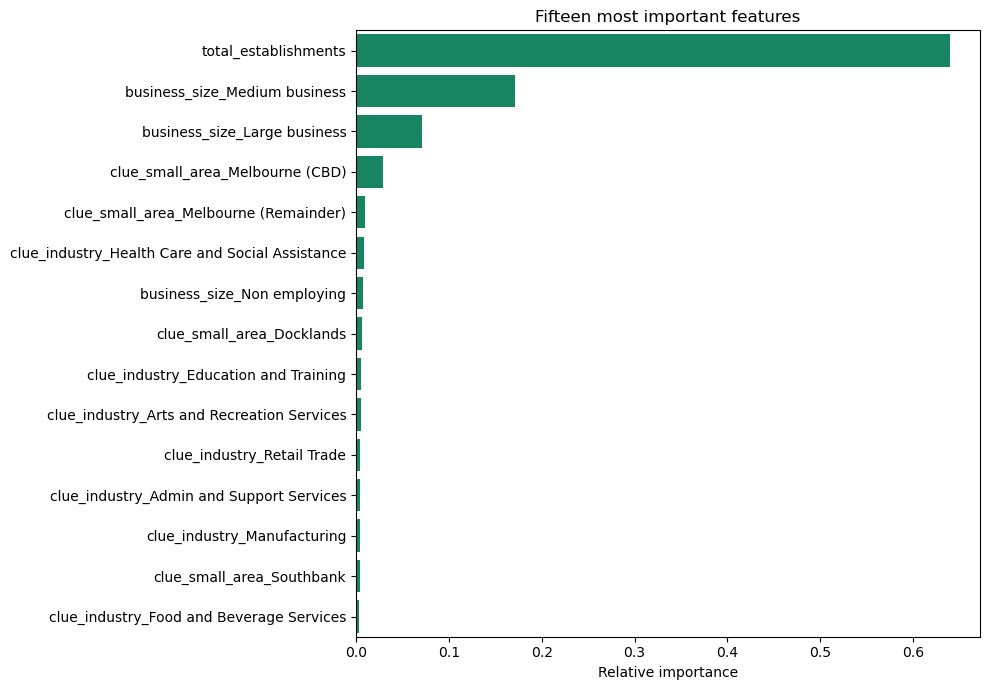

In [28]:
importances = pd.Series(
    model_pipeline.named_steps['regressor'].feature_importances_,
    index=feature_names,
).sort_values(ascending=False).head(15)

# Strip the ColumnTransformer prefixes so the labels read cleanly
importances.index = (
    importances.index
    .str.replace('numeric__', '', regex=False)
    .str.replace('categorical__', '', regex=False)
)

plt.figure(figsize=(10, 7))
sns.barplot(x=importances.values, y=importances.index, color=PRIMARY_GREEN)
plt.title('Fifteen most important features')
plt.xlabel('Relative importance')
plt.ylabel('')
plt.tight_layout()
plt.show()

<div class="usecase-body">

`total_establishments` dominates by a wide margin, which is what the R-squared discussion above anticipated. The categorical indicators that follow it are informative in a different way: they show which precincts and industries the model has found to carry job densities that differ from the average, once establishment count is accounted for.

This also sharpens the extension proposed in the conclusion. Dropping `total_establishments` and retraining would force the model to rely on the features further down this chart, which is a much harder problem &mdash; and a more useful one for a planner asking where jobs are likely to appear rather than how many follow from a known number of businesses.

</div>

<div id="section-6-3" class="usecase-sub-section-heading">
    6.3. Predicted against actual values
</div>

<div class="usecase-body">

Plotting predictions against the true test values shows where the model performs well and where it breaks down. Points falling on the diagonal are perfect predictions.

</div>

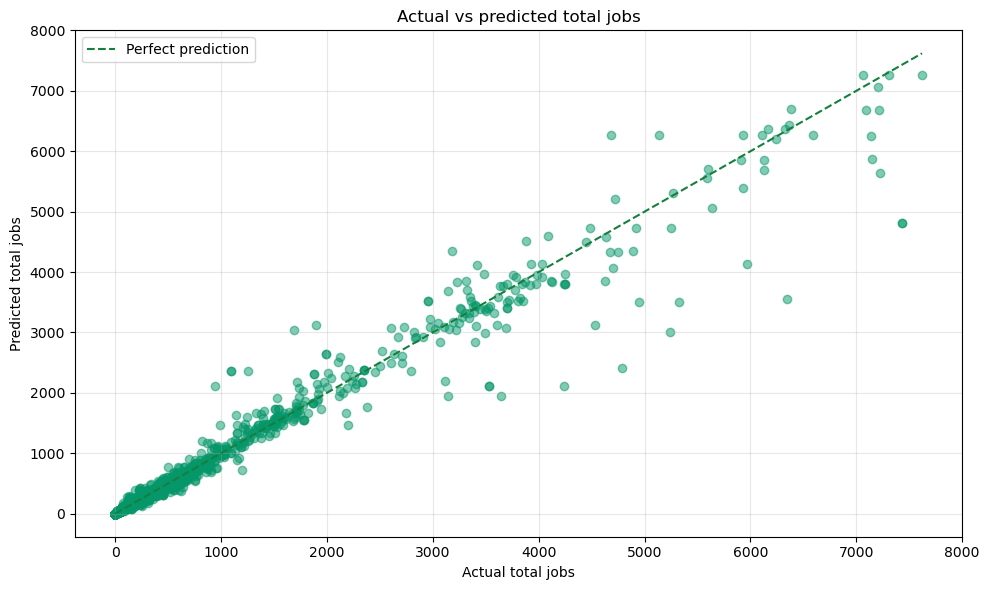

In [29]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color=PRIMARY_GREEN, alpha=0.5)

# Diagonal reference line: points on this line are perfect predictions
limits = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(limits, limits, color=DARK_GREEN, linestyle='--', label='Perfect prediction')

plt.title('Actual vs predicted total jobs')
plt.xlabel('Actual total jobs')
plt.ylabel('Predicted total jobs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<div class="usecase-body">

Predictions cluster tightly along the diagonal at the lower end of the range, where most of the data sits. Dispersion increases for the larger job counts, where there are fewer training examples to learn from. This is the expected behaviour for a skewed target and reinforces the point that the headline R-squared flatters the model's performance on the rarer, larger cases.

</div>

<div id="section-7" class="usecase-section-heading">
    7. Estimate jobs for a new combination of inputs
</div>

<div class="usecase-body">

The payoff for building a pipeline arrives here. The trained object accepts a raw DataFrame with the original column names, in any column order, and applies the same transformations it learned during training. There is no encoding step to repeat and no training column list to reindex against.

</div>

In [30]:
new_data = pd.DataFrame({
    'total_establishments': [50],
    'clue_small_area': ['West Melbourne (Residential)'],
    'clue_industry': ['Health Care and Social Assistance'],
    'business_size': ['Large business'],
})

# Raw columns in, prediction out. The pipeline handles the encoding internally.
predicted_jobs = model_pipeline.predict(new_data)

print(f'Predicted total jobs: {predicted_jobs[0]:,.0f}')

Predicted total jobs: 4,043


<div id="section-7-1" class="usecase-sub-section-heading">
    7.1. Behaviour on an unfamiliar category
</div>

<div class="usecase-body">

It is worth confirming that `handle_unknown='ignore'` does what section 5.2 claimed. The row below uses a small area label that does not exist in the CLUE classification, standing in for the kind of value that appears when a data source is revised or a new precinct is added.

The manual approach would have dropped this silently during the reindex. The pipeline encodes the unknown label as all zeros for that column and predicts from the remaining features, which is the behaviour you want &mdash; but note that it is a graceful degradation, not a correct answer. Production code should log unfamiliar categories rather than trusting the prediction unconditionally.

</div>

In [31]:
unseen_area = pd.DataFrame({
    'total_establishments': [50],
    'clue_small_area': ['Docklands Marina'],   # not a real CLUE small area
    'clue_industry': ['Health Care and Social Assistance'],
    'business_size': ['Large business'],
})

known_areas = X_train['clue_small_area'].unique()
print(f"'Docklands Marina' seen during training: {'Docklands Marina' in known_areas}")

print(f'Prediction: {model_pipeline.predict(unseen_area)[0]:,.0f} jobs')
print(f'Compare with the known-area prediction above: {predicted_jobs[0]:,.0f} jobs')

'Docklands Marina' seen during training: False
Prediction: 4,046 jobs
Compare with the known-area prediction above: 4,043 jobs


<div class="usecase-body">

Finally, it is worth inspecting what the pipeline actually passed to the regressor for the known-category row, so we can confirm the encoding behaved as expected.

</div>

In [32]:
# Inspect what the pipeline actually fed the regressor for this row
encoded_row = model_pipeline.named_steps['preprocess'].transform(new_data)

pd.DataFrame(encoded_row, columns=feature_names).loc[:, lambda d: (d != 0).any()]

,numeric__total_establishments,categorical__clue_small_area_West Melbourne (Residential),categorical__clue_industry_Health Care and Social Assistance,categorical__business_size_Large business
0,50.0,1.0,1.0,1.0


<div class="usecase-body">

Only four of the encoded features are non-zero: the establishment count and the three indicators matching the categories supplied. Every other indicator is zero. Being able to inspect this from the fitted pipeline, rather than from a separate encoded frame kept alongside it, is a small but practical benefit of building the workflow this way.

</div>

<div id="conclusion" class="usecase-unnumbered-heading"><b>Conclusion</b></div>

<div class="usecase-body"><b>What we achieved in this analysis</b></div>

<div class="usecase-body">

This analysis took CLUE employment data from a live API through to a working model. The descriptive work showed that jobs in Melbourne are heavily concentrated in a small number of industries: Business Services, Finance and Insurance, Public Administration and Safety, and Health Care together account for a large share of total employment, which makes them the natural focus for workforce planning. The ranking by jobs also differs from the ranking by establishments, because industries such as Retail Trade and Food and Beverage Services are dominated by small businesses.

The modelling then demonstrated that a Random Forest can estimate job counts for combinations of small area, industry and business size that are not directly observed in the published data. For a workforce planner, that fills a real gap: CLUE suppresses any cell covering two or fewer businesses, so the combinations most relevant to an emerging sector in a given precinct are often the ones missing from the table.

</div>

<div class="usecase-body"><b>What we learned from this analysis</b></div>

<div class="usecase-body">

Missing values in administrative data are rarely random. Almost a third of the <code>total_jobs</code> figures are absent, and they cluster around combinations with very few establishments, reflecting confidentiality suppression rather than an absence of activity. The treatment applied to them changes what the model learns, which is why the substitution was made explicitly rather than inside the pipeline.

Structuring the model as a scikit-learn pipeline is what makes it safe to hand over to someone other than its author. Preprocessing travels with the estimator, inference accepts raw columns, unfamiliar categories degrade gracefully instead of failing, and cross-validation measures what it claims to measure. The object can be serialised with <code>joblib.dump</code> and loaded into a scheduled job or an application without the encoding logic being reimplemented alongside it.

The main caution to carry forward is that the strong headline metrics rest largely on the relationship between establishment counts and job counts, as the feature importance chart makes plain. The metrics should be read as a measure of fit rather than as evidence that the model has learned subtle industry or location effects.

</div>

<div class="usecase-body"><b>Observations for further opportunities</b></div>

<div class="usecase-body">

A natural extension would be to drop <code>total_establishments</code> from the feature set and test how much predictive power remains in the categorical variables alone &mdash; a harder problem, and a more informative one for planning purposes. A second would be to retrieve the parallel ANZSIC industry series from the portal and merge it back in, giving a second industry classification to compare against. A third would be to retain the high job counts removed as outliers and apply a log transformation to the target instead, so the model is trained to handle the largest employers rather than excluding them. Finally, wrapping the pipeline in <code>GridSearchCV</code> to tune the forest's depth and tree count is now straightforward, because the pipeline refits its preprocessing correctly inside every fold.

</div>